In [1]:
import pandas as pd
import sys                          
import numpy as np             # Data manipulation 
from sklearn.decomposition import PCA        # The main algorithm
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from collections import defaultdict, Counter # Utils
sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [5]:
data_factorySolarGen = pd.read_csv('Generacion_fotovoltaica.csv')
data_gridInput = pd.read_csv('Consumo.csv')
data_Weather = pd.read_csv('Meteorologia.csv')
data_CarbonIntensity23 = pd.read_csv('ES_2023_hourly.csv')
data_CarbonIntensity24 = pd.read_csv('ES_2024_hourly.csv')
data_CarbonIntensity = pd.concat([data_CarbonIntensity23, data_CarbonIntensity24], ignore_index=True)
data_factorySolarUse = pd.read_csv('Consumo_fotovoltaica.csv')

data_CDM2023 = pd.read_csv('ComunidadData/2023.csv',delimiter=';')
data_CDM2023 = data_CDM2023.drop(columns=data_CDM2023.filter(regex=r'^v\d{2}$').columns)
data_CDM2023 = data_CDM2023.drop(columns=['punto_muestreo'])

data_CDM2023 = data_CDM2023[data_CDM2023['magnitud']==88]

data_CDM2023['municipio'].value_counts()

municipio
5      365
47     365
80     365
74     365
7      365
67     365
65     365
6      365
58     365
120    365
49     365
45     365
92     365
180    365
171    365
161    365
16     365
148    365
14     365
133    365
13     365
123    365
9      365
102    364
134    294
115    285
106    272
127    236
Name: count, dtype: int64

In [3]:
def renameAndIndex(df,datetime):
    df=df.rename(columns={datetime:'TIMESTAMP'})
    df['TIMESTAMP']=pd.to_datetime(df['TIMESTAMP'])
    df.set_index('TIMESTAMP', inplace=True)
    return df

In [4]:
data_factorySolarGen = renameAndIndex(data_factorySolarGen,'FECHA')
data_gridInput = renameAndIndex(data_gridInput,'FECHA')
data_Weather = renameAndIndex(data_Weather,'FORECAST_TIMESTAMP')
data_CarbonIntensity = renameAndIndex(data_CarbonIntensity,'Datetime (UTC)')
data_factorySolarUse = renameAndIndex(data_factorySolarUse,'FECHA')

In [5]:
allDatasets = {
    "factorySolarGen": data_factorySolarGen,
    "gridInput": data_gridInput,
    "weather": data_Weather,
    "carbonIntensity": data_CarbonIntensity,
    "factorySolarUse": data_factorySolarUse
}

minMaxDates = {}
for name, dataset in allDatasets.items():
    min_date = dataset.index.min()
    max_date = dataset.index.max()
    dataLen = len(dataset)
    minMaxDates[name] = {"min": min_date, "max": max_date, "rows":dataLen}

timeframes = pd.DataFrame(minMaxDates)

timeframes


,factorySolarGen,gridInput,weather,carbonIntensity,factorySolarUse
min,2023-07-24 11:00:00,2023-07-24 11:00:00,2023-07-24 11:00:00+00:00,2023-01-01 00:00:00,2024-09-01 00:00:00+02:00
max,2024-08-31 23:00:00,2024-08-31 23:00:00,2024-10-31 23:00:00+00:00,2024-12-31 23:00:00,2024-10-17 23:00:00+02:00
rows,9708,9708,100557,17544,1128


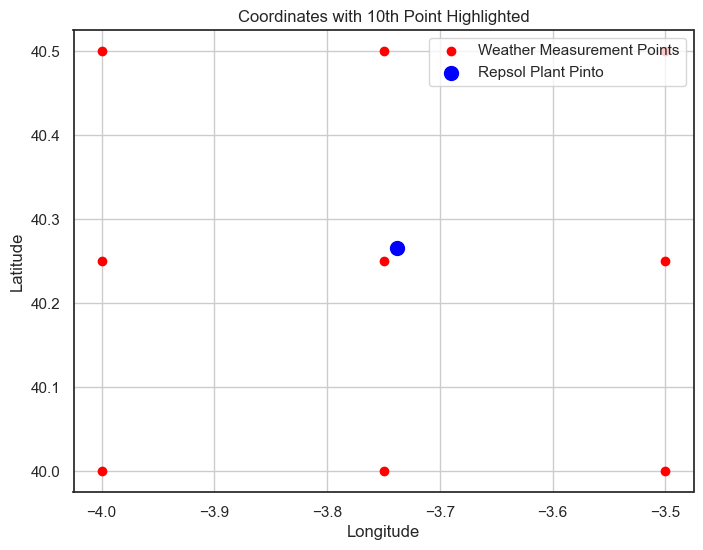

In [6]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
repsolPintoCoords = [40.265468,-3.738145]

coords.append(repsolPintoCoords)
import folium

# Center map roughly on the middle point
center_lat = sum([lat for lat, _ in coords]) / len(coords)
center_lon = sum([lon for _, lon in coords]) / len(coords)

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Add all points to map
for i, (lat, lon) in enumerate(coords):
    icon_color = 'blue' if i == 9 else 'red'  # Different color for the 10th point
    folium.Marker(
        location=[lat, lon],
        popup=f'Point {i+1}',
        icon=folium.Icon(color=icon_color,icon='sun')
    ).add_to(m)

# Save to file
m.save("grid_points_map.html")

normal = coords[:-1]
special = coords[-1:]

plt.figure(figsize=(8, 6))

# Normal points in red
plt.scatter([lon for _, lon in normal], [lat for lat, _ in normal], color='red', label='Weather Measurement Points')

# Special point in blue
plt.scatter(special[0][1], special[0][0], color='blue', s=100, label='Repsol Plant Pinto')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Coordinates with 10th Point Highlighted')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
coords

# Since the weather data is collected from 9 distinct points, according to the EDA, we can average these 9 points to get an accurate reading, as we don't know exact factory location

data_Weather.groupby('TIMESTAMP').mean()


,LATITUDE,LONGITUDE,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00+00:00,40.25,-3.75,5.176383,2.306685,17.577778,0.004644,301.823414,18000.0,300.332920,320.641024,...,94006.964236,2.700000,299.178662,301.843240,293.290378,324.906396,0.000000,315.466679,5.985768,2.433457
2023-07-24 12:00:00+00:00,40.25,-3.75,5.670802,2.579575,16.988889,0.004856,303.187798,21600.0,301.359812,324.429913,...,93949.704861,3.800000,300.411111,303.219008,293.290378,325.770036,0.000000,317.400000,6.652786,2.790844
2023-07-24 13:00:00+00:00,40.25,-3.75,6.260587,2.442148,17.077778,0.005225,304.332392,3600.0,302.303198,352.366667,...,93885.935417,38.833333,301.517803,304.326211,303.222222,326.296606,0.000000,318.032850,7.447305,2.665181
2023-07-24 14:00:00+00:00,40.25,-3.75,7.004427,2.025345,17.266667,0.005513,305.103729,7200.0,302.988475,356.926508,...,93829.203819,23.177778,302.366265,305.123018,303.222222,327.157633,0.000000,317.471498,8.407716,2.233926
2023-07-24 15:00:00+00:00,40.25,-3.75,7.471493,2.054768,17.411111,0.005703,305.553950,10800.0,303.401274,360.544444,...,93770.919444,58.177778,303.032275,305.617803,303.222222,330.289266,0.000000,315.935266,8.912477,2.333355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00+00:00,40.25,-3.75,1.712167,-0.120578,73.222222,0.008330,288.451378,0.0,288.458230,332.734110,...,94665.164583,42.044444,288.438051,289.342572,288.244711,295.169328,0.013889,287.852675,2.547099,0.112466
2024-10-31 20:00:00+00:00,40.25,-3.75,1.172493,0.060525,75.133333,0.008365,288.053681,0.0,288.046803,326.544554,...,94687.728819,54.911111,288.217674,289.467016,287.635614,295.584785,0.013889,287.270662,1.844787,0.230565
2024-10-31 21:00:00+00:00,40.25,-3.75,0.838918,0.100157,74.722222,0.008353,288.091836,0.0,288.100517,328.326836,...,94711.029167,71.344444,288.150030,289.579238,287.398305,295.179774,0.013889,287.248275,1.417429,0.248963


In [8]:
from geopy.distance import geodesic  # accurate distance calculation

grid_coords = coords
target_coord = repsolPintoCoords

distances = [geodesic(coord, target_coord).kilometers for coord in grid_coords]

inv_distances = [1/d if d != 0 else 1e9 for d in distances]  # Avoid division by zero
total = sum(inv_distances)
weights = [w/total for w in inv_distances]

point_names = [f"point{i+1}" for i in range(len(grid_coords))]
weight_mapping = dict(zip(point_names, weights))

In [9]:
point_labels = [f"point{i+1}" for i in range(len(coords))]

coord_to_label = {tuple(coord): label for coord, label in zip(coords, point_labels)}

data_Weather['point'] = data_Weather[['LATITUDE', 'LONGITUDE']].apply(
    lambda row: coord_to_label.get((row['LATITUDE'], row['LONGITUDE']), None),
    axis=1
)

data_Weather['weight'] = data_Weather['point'].map(weight_mapping)

columns_to_weight = [col for col in data_Weather.columns if col not in ['LATITUDE', 'LONGITUDE','point']]

for col in columns_to_weight:
    data_Weather[col] = data_Weather[col] * data_Weather['weight']

#

#data_Weather = data_Weather.groupby('TIMESTAMP').mean()

data_Weather = data_Weather[data_Weather['point']=='point5']

data_Weather = data_Weather.drop(columns=['point','weight','LATITUDE','LONGITUDE'])

data_Weather.index = data_Weather.index.tz_convert(None)

data_Weather

,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,4.136662,1.939803,11.159858,0.002942,193.545204,11544.681021,192.632002,204.474061,366.235764,5.066942,...,60339.079072,2.308936,191.756294,193.586425,187.602022,208.321458,0.0,202.993982,4.700674,1.996882
2023-07-24 12:00:00,4.307678,2.592292,11.223995,0.003145,194.249248,13853.617225,193.098209,207.039545,408.271231,5.599673,...,60305.433142,2.308936,192.411350,194.312023,187.602022,208.960887,0.0,204.148443,4.939632,2.682898
2023-07-24 13:00:00,4.673122,2.882559,11.095721,0.003322,195.011863,2308.936204,193.696144,225.698514,629.223598,5.838558,...,60264.305215,25.975532,193.114024,194.986520,194.271327,209.148961,0.0,204.390429,5.424271,3.029170
2023-07-24 14:00:00,5.401759,2.881759,10.903310,0.003435,195.542208,4617.872408,194.171293,228.295253,615.126260,6.548630,...,60230.883765,3.206856,193.722341,195.547453,194.271327,209.594304,0.0,203.709708,6.318892,3.086088
2023-07-24 15:00:00,5.597277,3.120834,11.223995,0.003644,195.859472,6926.808612,194.550071,229.931564,590.407815,7.073972,...,60187.344684,46.178724,194.292027,195.871920,194.271327,212.137319,0.0,202.631771,6.578494,3.470545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00,2.690161,-0.362389,53.233807,0.005487,183.968939,0.000000,183.975472,196.929952,0.000000,3.854769,...,60766.474788,5.195106,184.080114,185.413502,183.770114,189.655161,0.0,183.686855,3.924756,-0.383241
2024-10-31 20:00:00,1.739002,0.115783,50.989008,0.005466,184.335285,0.000000,184.324460,197.029293,0.000000,2.061473,...,60775.359783,20.074918,184.545935,185.419916,183.746463,190.042771,0.0,183.776781,2.564279,0.221279
2024-10-31 21:00:00,1.404622,0.146191,50.860734,0.005443,184.331251,0.000000,184.351784,199.918352,0.000000,1.736955,...,60793.496557,62.469552,184.449103,185.464812,183.746764,189.733125,0.0,183.505874,2.083520,0.235929


In [10]:
data_All = pd.concat([
    data_Weather.add_prefix("W_"),
    data_factorySolarGen.add_prefix("SG_"),
    data_gridInput.add_prefix("GI_"),
], axis=1, join='outer')

In [11]:
data_All.to_csv('cleaned_data.csv')

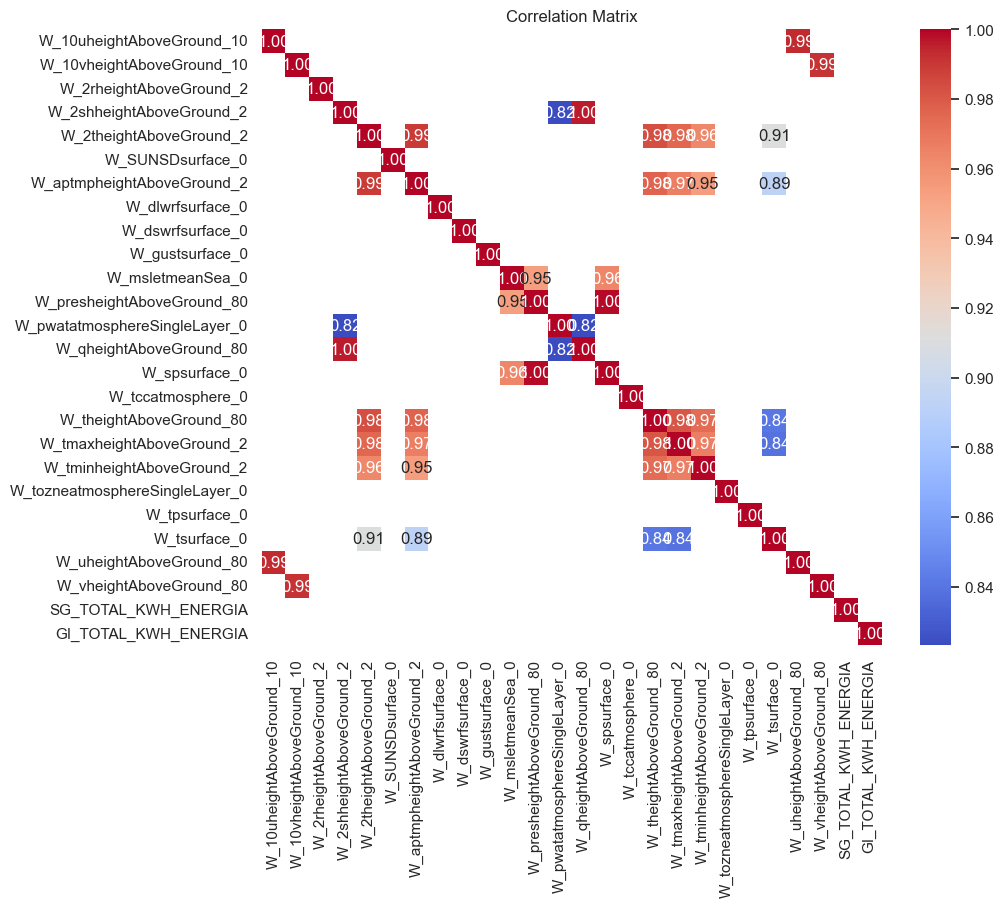

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = data_All.corr()
filtered_corr = correlation_matrix[correlation_matrix.abs() > 0.8]
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [13]:
data_All.drop(columns=[])

,W_10uheightAboveGround_10,W_10vheightAboveGround_10,W_2rheightAboveGround_2,W_2shheightAboveGround_2,W_2theightAboveGround_2,W_SUNSDsurface_0,W_aptmpheightAboveGround_2,W_dlwrfsurface_0,W_dswrfsurface_0,W_gustsurface_0,...,W_theightAboveGround_80,W_tmaxheightAboveGround_2,W_tminheightAboveGround_2,W_tozneatmosphereSingleLayer_0,W_tpsurface_0,W_tsurface_0,W_uheightAboveGround_80,W_vheightAboveGround_80,SG_TOTAL_KWH_ENERGIA,GI_TOTAL_KWH_ENERGIA
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,4.136662,1.939803,11.159858,0.002942,193.545204,11544.681021,192.632002,204.474061,366.235764,5.066942,...,191.756294,193.586425,187.602022,208.321458,0.0,202.993982,4.700674,1.996882,NaN,506.012634
2023-07-24 12:00:00,4.307678,2.592292,11.223995,0.003145,194.249248,13853.617225,193.098209,207.039545,408.271231,5.599673,...,192.411350,194.312023,187.602022,208.960887,0.0,204.148443,4.939632,2.682898,115.66,456.551453
2023-07-24 13:00:00,4.673122,2.882559,11.095721,0.003322,195.011863,2308.936204,193.696144,225.698514,629.223598,5.838558,...,193.114024,194.986520,194.271327,209.148961,0.0,204.390429,5.424271,3.029170,129.98,395.318604
2023-07-24 14:00:00,5.401759,2.881759,10.903310,0.003435,195.542208,4617.872408,194.171293,228.295253,615.126260,6.548630,...,193.722341,195.547453,194.271327,209.594304,0.0,203.709708,6.318892,3.086088,134.35,330.052979
2023-07-24 15:00:00,5.597277,3.120834,11.223995,0.003644,195.859472,6926.808612,194.550071,229.931564,590.407815,7.073972,...,194.292027,195.871920,194.271327,212.137319,0.0,202.631771,6.578494,3.470545,133.90,183.146606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00,2.690161,-0.362389,53.233807,0.005487,183.968939,0.000000,183.975472,196.929952,0.000000,3.854769,...,184.080114,185.413502,183.770114,189.655161,0.0,183.686855,3.924756,-0.383241,NaN,NaN
2024-10-31 20:00:00,1.739002,0.115783,50.989008,0.005466,184.335285,0.000000,184.324460,197.029293,0.000000,2.061473,...,184.545935,185.419916,183.746463,190.042771,0.0,183.776781,2.564279,0.221279,NaN,NaN
2024-10-31 21:00:00,1.404622,0.146191,50.860734,0.005443,184.331251,0.000000,184.351784,199.918352,0.000000,1.736955,...,184.449103,185.464812,183.746764,189.733125,0.0,183.505874,2.083520,0.235929,NaN,NaN


## Principal Component Analysis

### Null Imputation

In [14]:
import numpy as np

numerical_columns = list(data_All.select_dtypes(include=[np.number]).columns)

impute = True # you can change this

if impute:
    # Use mean for numerical features
    for feature in data_All:
        v = data_All[feature].mean()
        if np.isnan(v):
            v = 0
        print("Filling %s with %s" % (feature, v))
        data_All[feature] = data_All[feature].fillna(v)

else:        
    # drop records
    data_All.dropna(inplace=True)

Filling W_10uheightAboveGround_10 with 0.9975013985660441
Filling W_10vheightAboveGround_10 with 0.2994724814920358
Filling W_2rheightAboveGround_2 with 33.45841022768494
Filling W_2shheightAboveGround_2 with 0.004124282851004923
Filling W_2theightAboveGround_2 with 186.53962668496683
Filling W_SUNSDsurface_0 with 3930.2426793092163
Filling W_aptmpheightAboveGround_2 with 186.04374829264518
Filling W_dlwrfsurface_0 with 208.23358029591046
Filling W_dswrfsurface_0 with 131.77929410141698
Filling W_gustsurface_0 with 3.816263536241949
Filling W_msletmeanSea_0 with 65142.993660644905
Filling W_presheightAboveGround_80 with 59993.64802323515
Filling W_pwatatmosphereSingleLayer_0 with 11.000415538703074
Filling W_qheightAboveGround_80 with 0.003996532994355518
Filling W_spsurface_0 with 60556.67267449342
Filling W_tccatmosphere_0 with 28.92116700968348
Filling W_theightAboveGround_80 with 186.4653323074978
Filling W_tmaxheightAboveGround_2 with 187.4265179985098
Filling W_tminheightAboveGro

In [15]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler().fit(data_All)
X_std = ss.transform(data_All)

#### Compute PCA

In [16]:
sklearn_pca = PCA()
Y_sklearn = sklearn_pca.fit_transform(X_std)

#### Eigenvector Explained Variance

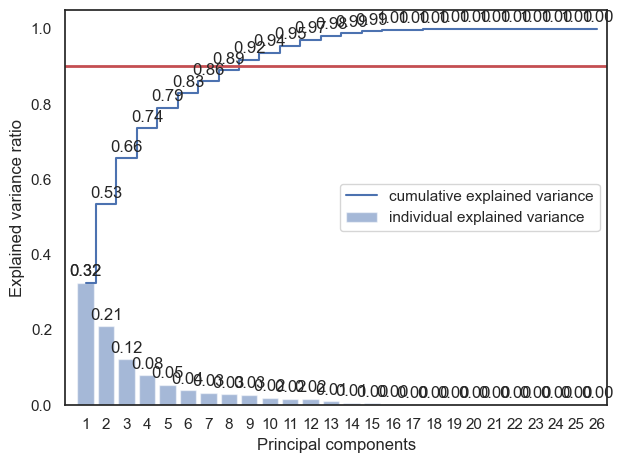

In [17]:
plt.bar(range(1,sklearn_pca.n_components_+1), sklearn_pca.explained_variance_ratio_, alpha=0.5, align='center',label='individual explained variance')
plt.step(range(1,sklearn_pca.n_components_+1), [sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)], where='mid',label='cumulative explained variance')
plt.axhline(y=0.90, linewidth=2, color = 'r')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
for i, ratio in enumerate(sklearn_pca.explained_variance_ratio_):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')
for i, ratio in enumerate([sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)]):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')

plt.xlim([0, sklearn_pca.n_components_+0.5])
plt.xticks(range(1, sklearn_pca.n_components_ + 1))
plt.legend(loc='best')
plt.tight_layout()

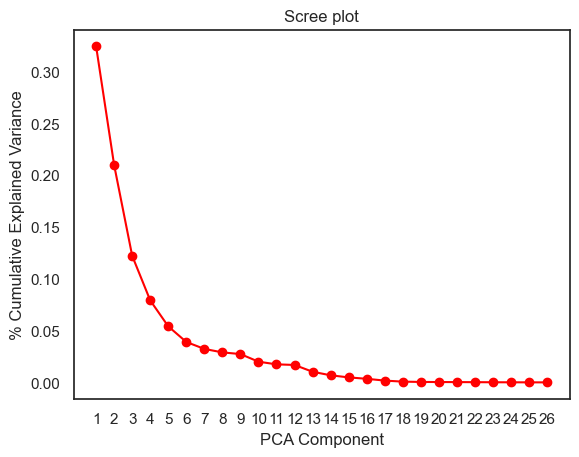

In [18]:
# Scree plot 
plt.plot(
    range(1,len(sklearn_pca.explained_variance_ratio_ )+1),
    sklearn_pca.explained_variance_ratio_,
    c='red', marker='o'
)
plt.xticks(range(1, len(sklearn_pca.explained_variance_ratio_) + 1))   
plt.xlabel('PCA Component')
plt.ylabel('% Cumulative Explained Variance')
plt.title('Scree plot')
plt.show()

In [19]:
VARIANCE_TO_KEEP = 0.85 # that would mean two componentes in our example
keep_recommend = [sklearn_pca.explained_variance_ratio_[:y].sum()>VARIANCE_TO_KEEP for y in range(1,sklearn_pca.n_components_+1)].count(False)
print("Number of components to keep to retain %s%% of the variance:" % (100*VARIANCE_TO_KEEP), keep_recommend, "out of the original", sklearn_pca.n_components_)
n_components = keep_recommend

Number of components to keep to retain 85.0% of the variance: 6 out of the original 26


In [20]:
sklearn_pca_final = PCA(n_components)
Y_sklearn = sklearn_pca_final.fit_transform(X_std)

In [21]:
# Shows Factor loadings = correlations between variables and factors
print ("")
print ("Factor loadings:")

pd.set_option('display.float_format', '{:.4f}'.format)

dfloadings=pd.DataFrame(
    data    = sklearn_pca_final.components_,
    columns = data_All.columns,
)

index_list=[]
for n in range(n_components):
    index_list.append("PC"+str(n+1))

dfloadings.index = index_list

# Hide low values so that it is clearer
dfloadings.T.where(abs(dfloadings.T) > 0.3  , "")  # we hide values lower than 0.25 to better display the relations


Factor loadings:


,PC1,PC2,PC3,PC4,PC5,PC6
W_10uheightAboveGround_10,,,,,,-0.3743
W_10vheightAboveGround_10,,,,0.3472,,0.4379
W_2rheightAboveGround_2,,,,,,
W_2shheightAboveGround_2,,,0.3718,,,
W_2theightAboveGround_2,0.3361,,,,,
W_SUNSDsurface_0,,,,,0.3136,
W_aptmpheightAboveGround_2,0.3333,,,,,
W_dlwrfsurface_0,,,,,,
W_dswrfsurface_0,,,-0.3103,,,
W_gustsurface_0,,-0.3093,,,,


#### Communalities

In [22]:
# Communalities
commun=[]

for col in dfloadings.columns:
    commun.append((dfloadings.iloc[0:3][col]**2).sum())
    
dfcommun = pd.DataFrame(commun,index=dfloadings.columns, columns=["Communalities"])
dfcommun.sort_values("Communalities", ascending=False)

,Communalities
W_qheightAboveGround_80,0.2014
W_2shheightAboveGround_2,0.1971
W_pwatatmosphereSingleLayer_0,0.1713
W_10uheightAboveGround_10,0.1473
W_2rheightAboveGround_2,0.1454
W_uheightAboveGround_80,0.1439
W_presheightAboveGround_80,0.1418
W_dswrfsurface_0,0.1415
W_spsurface_0,0.1406
W_msletmeanSea_0,0.1336


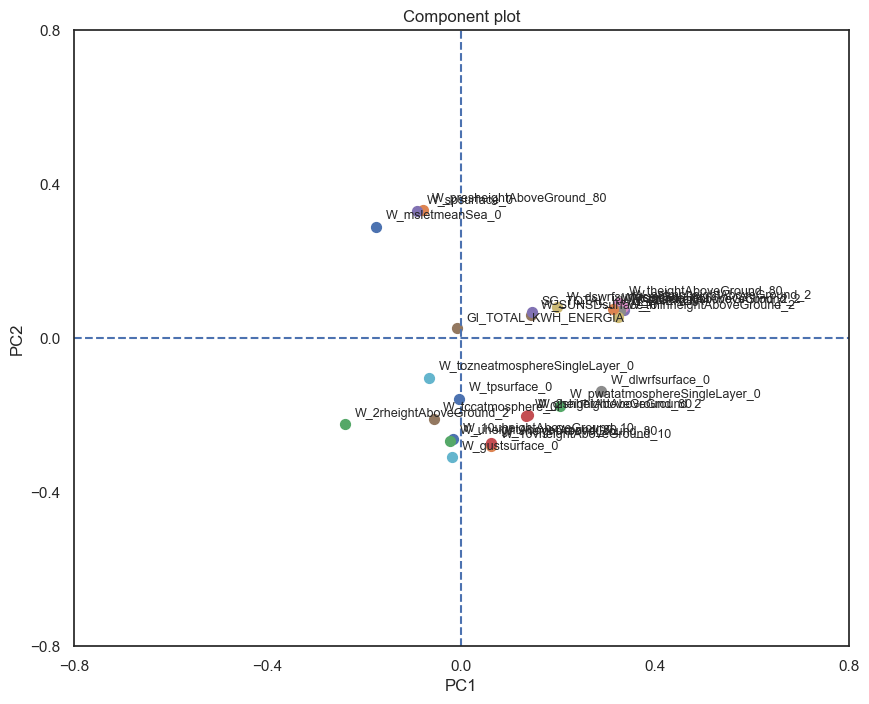

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Get the loadings of x and y axes
dfloadT = dfloadings.T

xs = dfloadT.PC1
ys = dfloadT.PC2
 
plt.figure(figsize=(10, 8))
plt.axvline(x=0, color='b', linestyle='dashed')
plt.axhline(y=0, color='b', linestyle='dashed')

# Plot the loadings on a scatterplot
for i, varnames in enumerate(dfloadings.columns):
    plt.scatter(xs.iloc[i], ys.iloc[i], s=50)
    
    # Slightly offset the text to avoid overlap
    plt.text(xs.iloc[i] + 0.02, ys.iloc[i] + 0.02, varnames, fontsize=9)

# Define the axes and show plot
xticks = np.linspace(-0.8, 0.8, num=5)
yticks = np.linspace(-0.8, 0.8, num=5)
plt.xticks(xticks)
plt.yticks(yticks)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Component plot')

# Save the plot and show it
plt.savefig('Component_plot.png', bbox_inches='tight')  # Avoid cutting parts off
plt.show()